<img src="./logo_UNSAM-Copy1.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

<center>
    
# Trabajo Final
# *Detección de la onda gravitacional GW150914 mediante Matched Filtering*
</center>

#### Nombre y Apellido: Matías Galperin (mugalperin@estudiantes.unsam.edu.ar)
#### Docentes: Mariano Llamedo Soria, Francisco Hernan Ledesma, David Ezequiel Benoit

In [6]:
import os
import urllib.request
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, correlate, welch, resample

## Bibliotecas y herramientas utilizadas

`os y urllib.request:` gestión de archivos locales y descarga de la plantilla teórica del chirp desde GWOSC, evitando descargas repetidas si el archivo ya existe.


`h5py:` lectura del formato HDF5, en el que GWOSC distribuye los datos de strain de LIGO. Cada archivo contiene, entre otros campos, el dataset strain/Strain con la serie temporal de deformación relativa $h(t)=ΔL/L$ medida por el interferómetro.
numpy: manipulación numérica de los arrays de strain (típicamente ~16.7 millones de muestras por archivo de 4096 s a 4096 Hz).


`matplotlib.pyplot:` graficación de la señal cruda, la PSD, el resultado del filtrado y la salida del matched filter.


`scipy.signal:` se importan puntualmente las funciones que sostienen las etapas del pipeline definidas en la propuesta:

`butter y filtfilt:` diseño de un filtro digital IIR Butterworth y su aplicación con fase cero, lo cual evita distorsionar la fase de la señal, algo clave en un chirp, donde la evolución temporal de la fase es la característica que se quiere preservar para el matched filtering.

`welch:` estimación de la densidad espectral de potencia (PSD) del ruido de fondo mediante el método de Welch, que reduce la varianza del estimador espectral respecto de una FFT simple sobre toda la ventana.

`correlate:` implementación de la correlación cruzada que constituye el núcleo del matched filter, la técnica óptima (en el sentido de máxima SNR) para detectar una forma de onda conocida inmersa en ruido aditivo.

`resample:` reacondicionamiento de la frecuencia de muestreo de la plantilla teórica del chirp para que coincida con la de los datos de strain (4096 Hz), condición necesaria para que la correlación cruzada tenga sentido muestra a muestra.

In [7]:
# ============================================================
# PARÁMETROS GENERALES
# ============================================================
FS = 4096                      # Frecuencia de muestreo (Hz)
GPS_START_ARCHIVO = 1126256640 # GPS de inicio de estos archivos (está en el nombre)
GPS_MERGER = 1126259462.4      # GPS oficial del merger de GW150914 (GWOSC)
CENTRO = GPS_MERGER - GPS_START_ARCHIVO   # ~2822.4 s -> ESTE era el bug
VENTANA = 16                   # segundos hacia cada lado del centro (recorte de 32 s)

BANDA_BAJA = 20.0    # Hz, corte inferior del pasabanda
BANDA_ALTA = 300.0   # Hz, corte superior del pasabanda
ORDEN_FILTRO = 4

ARCHIVOS = {
    'H1': 'H-H1_LOSC_4_V1-1126256640-4096.hdf5',
    'L1': 'L-L1_LOSC_4_V1-1126256640-4096.hdf5',
}

URL_TEMPLATE = 'https://www.gw-openscience.org/GW150914data/P150914/fig2-unfiltered-waveform-H.txt'
ARCHIVO_TEMPLATE = 'template_GW150914.txt'

## Parámetros iniciales

**Frecuencia de muestreo**

`FS = 4096` Hz es la frecuencia con la que GWOSC distribuye estos archivos de strain. Por el teorema de muestreo de Nyquist-Shannon, esto fija el límite superior de análisis en $f_{Nyq} = FS/2 = 2048$ Hz, ampliamente suficiente ya que la señal de interés (el chirp) evoluciona entre ~35 Hz y ~250 Hz antes de la fusión.

**Referencia temporal (GPS)**

Los datos de LIGO se indexan con tiempo GPS (segundos desde el 6 de enero de 1980, sin corrección por segundos bisiestos). El nombre del archivo indica el instante GPS de su primera muestra (`GPS_START_ARCHIVO`), mientras que `GPS_MERGER` es el instante oficial de la fusión publicado por la colaboración LIGO. La resta

$$\text{CENTRO} = \text{GPS\_MERGER} - \text{GPS\_START\_ARCHIVO} \approx 2822.4\ \text{s}$$

da la posición del merger *dentro* del archivo de 4096 s, que es lo que realmente se necesita para indexar el array de NumPy (que arranca en la muestra 0, no en el GPS absoluto). Este cálculo es el que corrige el desfasaje, ya que si no se hace esta traslación de referencia, se termina recortando una ventana de ruido arbitraria en lugar de la ventana que contiene el evento.

**Ventana de análisis**

`VENTANA = 16` s a cada lado del centro define un recorte total de 32 s. Este tamaño es un compromiso: debe ser lo suficientemente grande como para estimar la PSD del ruido de fondo con buena resolución en frecuencia ($\Delta f = 1/T$) y sin contaminarse por los bordes tras el filtrado, pero lo suficientemente chico como para que el ruido pueda considerarse aproximadamente estacionario en ese intervalo, supuesto necesario tanto para el método de Welch como para el matched filter clásico.

**Banda del filtro pasabanda**

`BANDA_BAJA = 20` Hz y `BANDA_ALTA = 300` Hz delimitan la región espectral donde LIGO tiene su mejor sensibilidad y donde se concentra la energía del chirp de GW150914 (que barre de ~35 a ~250 Hz). El corte inferior en 20 Hz descarta el ruido sísmico de baja frecuencia, dominante y de gran amplitud, mientras que el corte superior en 300 Hz elimina ruido de alta frecuencia sin recortar la parte final del chirp, donde la frecuencia instantánea es máxima justo antes de la fusión.

**Orden del filtro**

`ORDEN_FILTRO = 4` fija la pendiente de atenuación del filtro Butterworth (~24 dB/octava por los dos cortes al usarse como pasabanda). Se eligió un orden moderado porque un orden mayor, si bien atenuaría más rápido fuera de banda, introduce mayor distorsión de fase y ringing transitorio, indeseable al analizar una señal transitoria como el chirp.

**Archivos y plantilla**

El diccionario `ARCHIVOS` mapea cada detector (H1 = Hanford, L1 = Livingston) a su archivo HDF5 correspondiente, permitiendo iterar el mismo pipeline sobre ambos sin duplicar código.

`URL_TEMPLATE` y `ARCHIVO_TEMPLATE` apuntan a la forma de onda teórica del chirp publicada por GWOSC (la que se usará como plantilla de referencia para el matched filtering), evitando así tener que derivarla analíticamente a partir de las ecuaciones de relatividad numérica.

In [8]:
# ============================================================
# FUNCIONES
# ============================================================

def descargar_template(url=URL_TEMPLATE, destino=ARCHIVO_TEMPLATE):
    if not os.path.exists(destino):
        print("Descargando la plantilla desde GWOSC...")
        urllib.request.urlretrieve(url, destino)
        print("¡Descarga completa!")
    else:
        print(f"Usando plantilla ya descargada: {destino}")
    return destino


def cargar_template(path):
    datos = np.loadtxt(path)
    t_template = datos[:, 0]
    strain_template = datos[:, 1]

    dt = np.diff(t_template).mean()
    fs_template = 1.0 / dt
    print(f"Sample rate detectado en la plantilla: {fs_template:.1f} Hz")

    if abs(fs_template - FS) > 1.0:
        print(f"  -> Resampleando plantilla de {fs_template:.1f} Hz a {FS} Hz")
        n_nuevo = int(len(strain_template) * FS / fs_template)
        strain_template = resample(strain_template, n_nuevo)
        t_template = np.linspace(t_template[0], t_template[-1], n_nuevo)

    return t_template, strain_template


def cargar_strain(path):
    with h5py.File(path, 'r') as f:
        strain = f['strain/Strain'][()]
    return strain


def recortar_ventana(strain, fs=FS, centro=CENTRO, ventana=VENTANA):
    idx_inicio = int((centro - ventana) * fs)
    idx_fin = int((centro + ventana) * fs)
    seg = strain[idx_inicio:idx_fin].copy()

    # Los archivos LOSC pueden tener NaNs en tramos sin datos válidos
    n_nan = np.isnan(seg).sum()
    if n_nan > 0:
        print(f"  Aviso: {n_nan} muestras NaN en la ventana, se rellenan con 0")
        seg = np.nan_to_num(seg, nan=0.0)

    tiempo = np.arange(idx_inicio, idx_fin) / fs
    return tiempo, seg


def filtrar_pasabanda(x, fs=FS, low=BANDA_BAJA, high=BANDA_ALTA, orden=ORDEN_FILTRO):
    nyq = 0.5 * fs
    b, a = butter(orden, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, x)


def calcular_psd(x, fs=FS):
    return welch(x, fs=fs, nperseg=fs)


def blanquear(x, fs, psd_freqs, psd_vals, ventanear=True):
    n = len(x)
    if ventanear:
        win = signal.windows.tukey(n, alpha=0.1)
        x = x * win
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    psd_interp = np.interp(freqs, psd_freqs, psd_vals)
    psd_interp[psd_interp == 0] = np.min(psd_interp[psd_interp > 0])
    X_blanco = X / np.sqrt(psd_interp)
    x_blanco = np.fft.irfft(X_blanco, n=n)
    return x_blanco


def matched_filter(x_blanco, template_blanco, fs=FS):
    corr = correlate(x_blanco, template_blanco, mode='valid')
    snr = np.abs(corr)
    offset = len(template_blanco) // 2
    return snr, offset

## Funciones del pipeline

**`descargar_template` y `cargar_template`**

La plantilla teórica del chirp (publicada por GWOSC a partir del ajuste de relatividad numérica al evento real) se descarga una única vez y se cachea en disco. Como el archivo de la plantilla puede tener una frecuencia de muestreo distinta a la de los datos de strain, `cargar_template` estima la frecuencia de muestreo real a partir del espaciado temporal y, si no coincide con `FS`, resamplea la plantilla mediante el método de Fourier. Esto es indispensable para que la correlación cruzada del matched filter tenga sentido, la señal y la plantilla deben estar expresadas en la misma base temporal, muestra a muestra.

**`cargar_strain`**

Lee directamente el dataset `strain/Strain` del archivo HDF5, que contiene la serie temporal de deformación relativa $h(t)$ medida por el interferómetro. Es la etapa de adquisición de datos.

**`recortar_ventana`**

Traduce el instante GPS del merger (ya corregido por el offset del archivo, `CENTRO`) a un rango de índices del array, y recorta los 32 s de interés. Un punto importante es el manejo de los NaNs: los archivos de GWOSC marcan con `NaN` los tramos que no cumplen los criterios de calidad de datos ("science quality"). Rellenarlos con cero es una simplificación razonable en este contexto, ya que si la ventana elegida está bien centrada en el evento real, estos gaps deberían ser escasos o inexistentes; de lo contrario, introducirían una discontinuidad que se propagaría como ruido espurio en el filtrado y el blanqueo posteriores.

**`filtrar_pasabanda`**

Implementa el filtro Butterworth pasabanda descripto en los parámetros. La normalización `low/nyq`, `high/nyq` expresa las frecuencias de corte como fracción de la frecuencia de Nyquist, que es la convención que exige `scipy.signal.butter`. El uso de `filtfilt` en lugar de una convolución simple aplica el filtro dos veces, lo que **cancela la distorsión de fase** que introduciría un filtro IIR causal común, a costa de duplicar el orden efectivo del filtro.

**`calcular_psd`**

Estima la densidad espectral de potencia del ruido de fondo mediante el método de Welch, usando `nperseg=fs` (segmentos de 1 s), lo cual da una resolución en frecuencia de 1 Hz. Esta PSD es la caracterización estadística del ruido instrumental que se usa después para diseñar el blanqueo: se asume que, en la ventana de 32 s, el ruido es aproximadamente estacionario en sentido amplio, condición necesaria para que una única PSD promedio sea representativa de todo el segmento.

**`blanquear`**

El **blanqueo (whitening)** consiste en dividir el espectro de la señal por $\sqrt{S_n(f)}$, donde $S_n(f)$ es la PSD del ruido:

$$X_{blanco}(f) = \frac{X(f)}{\sqrt{S_n(f)}}$$

El objetivo es que, tras esta operación, el ruido de fondo tenga una PSD aproximadamente plana. Esto es un requisito teórico del matched filter óptimo: la correlación cruzada simple entre señal y plantilla solo maximiza la SNR cuando el ruido de fondo es blanco; si el ruido tiene un color espectral hay que blanquear primero para que la comparación entre frecuencias sea "justa" y no esté dominada por las bandas donde el instrumento es más ruidoso.

Se aplica una ventana Tukey, ya que sin ventaneo el segmento de datos se trata implícitamente como si fuera periódico, y el salto abrupto entre el último y el primer valor del segmento (que en general no coinciden) genera una discontinuidad artificial. Por el fenómeno de spectral leakage, esa discontinuidad esparce energía espuria en todas las frecuencias del espectro, y como esto depende únicamente de la posición dentro del array, puede producir picos falsos idénticos en H1 y L1 en el mismo índice temporal.

**`matched_filter`**

Implementa la detección, la correlación cruzada entre la señal blanqueada y la plantilla blanqueada (con la misma PSD, condición necesaria para que ambas estén en la misma escala espectral). El matched filter es, por un resultado clásico de teoría de detección de señales, el filtro lineal que maximiza la relación señal-ruido de salida cuando se busca una forma de onda conocida inmersa en ruido aditivo. De aquí sale su uso como herramienta estándar en la detección de ondas gravitacionales, donde la forma del chirp es conocida a priori a partir de la relatividad numérica.

El uso de `mode='valid'` evita que la plantilla se superponga parcialmente con los bordes del segmento, lo que en `mode='full'` o `'same'` generaría correlaciones espurias en los extremos. El `offset` calculado como la mitad del largo de la plantilla corrige el corrimiento de índice que introduce este modo, para que el instante de máxima correlación se pueda traducir correctamente al eje temporal original de la señal.

In [20]:
import urllib.request

URLS_STRAIN = {
    'H1': 'https://gwosc.org/eventapi/json/GW150914/v3/H-H1_LOSC_4_V1-1126256640-4096.hdf5',
    'L1': 'https://gwosc.org/eventapi/json/GW150914/v3/L-L1_LOSC_4_V1-1126256640-4096.hdf5',
}
# (buscá el link exacto de descarga directa en la página de GWOSC del evento)

for detector, url in URLS_STRAIN.items():
    destino = ARCHIVOS[detector]
    if not os.path.exists(destino):
        print(f"Descargando {destino}...")
        urllib.request.urlretrieve(url, destino)

Usando plantilla ya descargada: template_GW150914.txt
Sample rate detectado en la plantilla: 16384.0 Hz
  -> Resampleando plantilla de 16384.0 Hz a 4096 Hz


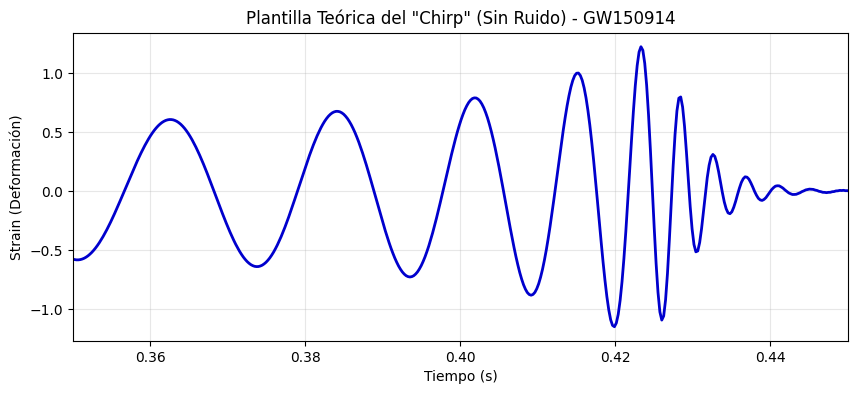

In [21]:
# ============================================================
# 1. PLANTILLA TEÓRICA
# ============================================================
path_template = descargar_template()
t_template, strain_template = cargar_template(path_template)

plt.figure(figsize=(10, 4))
plt.plot(t_template, strain_template, color='mediumblue', linewidth=2)
plt.title('Plantilla Teórica del "Chirp" (Sin Ruido) - GW150914')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain (Deformación)')
plt.xlim(0.35, 0.45)
plt.grid(True, alpha=0.3)
plt.show()

## Visualización de la plantilla teórica del chirp

Esta celda descarga la plantilla teórica del chirp de GW150914 y grafica un recorte de 0.35 a 0.45 s para poder apreciar en detalle su estructura temporal.

La plantilla no proviene de un modelo analítico simplificado (como un chirp lineal en frecuencia), sino de la forma de onda publicada por la colaboración LIGO en Abbott et al. (2016), obtenida mediante el método de relatividad numérica, el cual consiste en discretizar del espacio-tiempo en una grilla, plantear las condiciones iniciales (masas, spins, separación) y se evoluciona el sistema paso a paso resolviendo las ecuaciones de Einstein en cada punto utilizando supercomputadoras.

En el gráfico resultante se observa con claridad la firma característica de un chirp gravitacional:

- **Frecuencia creciente**: el período de cada oscilación se acorta progresivamente a medida que avanza el tiempo, reflejando que los dos agujeros negros orbitan cada vez más rápido a medida que pierden energía orbital en forma de radiación gravitacional (según las ecuaciones de Peters, la frecuencia orbital crece como $f \propto (t_c - t)^{-3/8}$ cerca de la coalescencia, donde $t_c$ es el instante de fusión).
- **Amplitud creciente**: los picos de strain aumentan en magnitud a medida que los agujeros negros se acercan, ya que la amplitud de la radiación emitida escala con la aceleración del sistema y por ende con la frecuencia orbital.
- **Fusión (merger)**: alrededor de t ≈ 0.42 s se alcanza el pico máximo de amplitud, correspondiente al instante en que los dos agujeros negros se fusionan en uno solo.
- **Ringdown**: inmediatamente después del pico, la amplitud decae rápidamente en unas pocas oscilaciones — es el agujero negro final "asentándose" en su configuración de equilibrio, radiando la energía sobrante en modos cuasi-normales, de forma análoga a una campana que deja de vibrar tras ser golpeada.

Esta forma de onda es la que se usará como referencia en la etapa de matched filtering: al ser conocida con precisión (a diferencia del strain real, dominado por ruido), permite correlacionarla contra los datos de H1 y L1 para ubicar el instante en el que esta firma temporal-espectral particular está efectivamente presente en las mediciones.

In [22]:
resultados = {}
detector = 'H1'
nombre_archivo = ARCHIVOS[detector]
print(f"\n=== Procesando {detector} ===")

strain = cargar_strain(nombre_archivo)
tiempo, seg = recortar_ventana(strain)


=== Procesando H1 ===


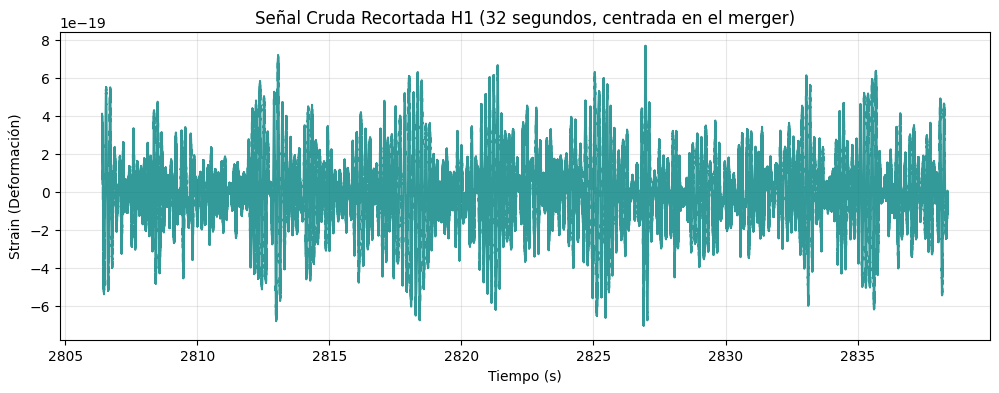

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(tiempo, seg, color='teal', alpha=0.8)
plt.title(f'Señal Cruda Recortada {detector} (32 segundos, centrada en el merger)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain (Deformación)')
plt.grid(True, alpha=0.3)
plt.show()

## Visualización de la señal cruda recortada (H1)

Este gráfico muestra los 32 s de strain de H1 recortados alrededor del merger, sin ningún procesamiento aplicado.

La señal se ve como ruido de banda ancha, con fluctuaciones de amplitud del orden de $10^{-19}$ y con una envolvente que varía de forma aparentemente aleatoria a lo largo de los 32 s. Esto es completamente esperable y es, de hecho, el punto central que motiva todo el resto del pipeline: la amplitud del chirp de GW150914 es del orden de $10^{-21}$, es decir, **dos órdenes de magnitud menor** que el nivel de ruido instrumental típico visible en este gráfico. En términos de potencia, la señal está enterrada ~4 órdenes de magnitud por debajo del ruido de fondo.

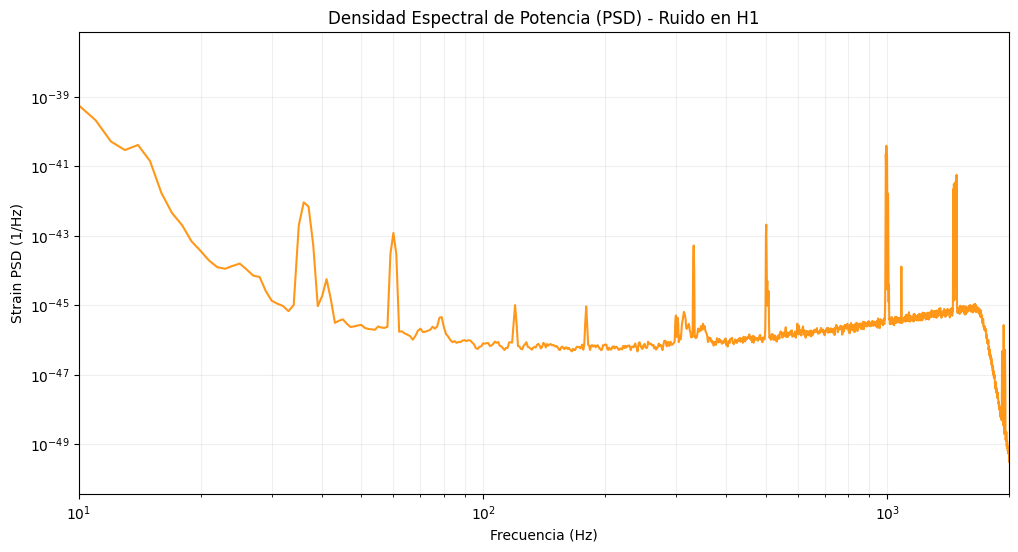

In [24]:
freqs_psd, psd = calcular_psd(seg)
plt.figure(figsize=(12, 6))
plt.loglog(freqs_psd, psd, color='darkorange', linewidth=1.5, alpha=0.9)
plt.title(f'Densidad Espectral de Potencia (PSD) - Ruido en {detector}')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Strain PSD (1/Hz)')
plt.xlim(10, 2000)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## Densidad espectral de potencia del ruido (H1)

Esta celda estima la PSD del segmento de 32 s mediante el método de Welch (`calcular_psd`) y la grafica en escala logarítmica en ambos ejes, que es la representación estándar en la literatura de LIGO para mostrar la curva de sensibilidad del instrumento.

El gráfico revela con claridad las distintas fuentes de ruido que dominan cada banda de frecuencia, y confirma que la estimación espectral se está realizando correctamente:

- **Ruido sísmico (< ~40 Hz)**: la pendiente pronunciada y decreciente hacia frecuencias bajas corresponde al acoplamiento de vibraciones del terreno (tráfico, actividad geológica, olas oceánicas lejanas) con los espejos del interferómetro. Es la razón principal por la que el filtro pasabanda del pipeline tiene su corte inferior en 20 Hz: por debajo de esa frecuencia el ruido crece varios órdenes de magnitud y ahogaría cualquier intento de detección.

- **Región intermedia (~40-500 Hz), el "valle" de sensibilidad**: es donde la PSD alcanza sus valores más bajos, y por lo tanto donde el detector es más sensible. No es casualidad que sea justamente la banda donde se concentra la energía del chirp de GW150914 (~35 a 250 Hz): los detectores están diseñados específicamente para maximizar sensibilidad en el rango de frecuencias esperado para fusiones de agujeros negros.

- **Picos angostos ("líneas espectrales")**: se observan resonancias muy definidas, por ejemplo cerca de 35, 60, 300, 500, 1000 y 1500 Hz. Corresponden a dos orígenes distintos:
  - Los picos en 60 Hz y sus armónicos (300, 500... no todos exactos pero cercanos) están asociados a interferencia de la línea eléctrica de la red (60 Hz en EE.UU.).
  - Los picos angostos y muy prominentes cerca de 500, 1000 y 1500 Hz son los llamados **"violin modes"**: resonancias mecánicas de los cables de suspensión de los espejos del interferómetro, que vibran como cuerdas de un instrumento musical (de ahí el nombre) en sus modos normales y armónicos.

- **Caída abrupta cerca de 2000 Hz**: corresponde a la frecuencia de Nyquist ($FS/2 = 2048$ Hz), límite superior de lo que puede representarse sin aliasing dado el muestreo a 4096 Hz.

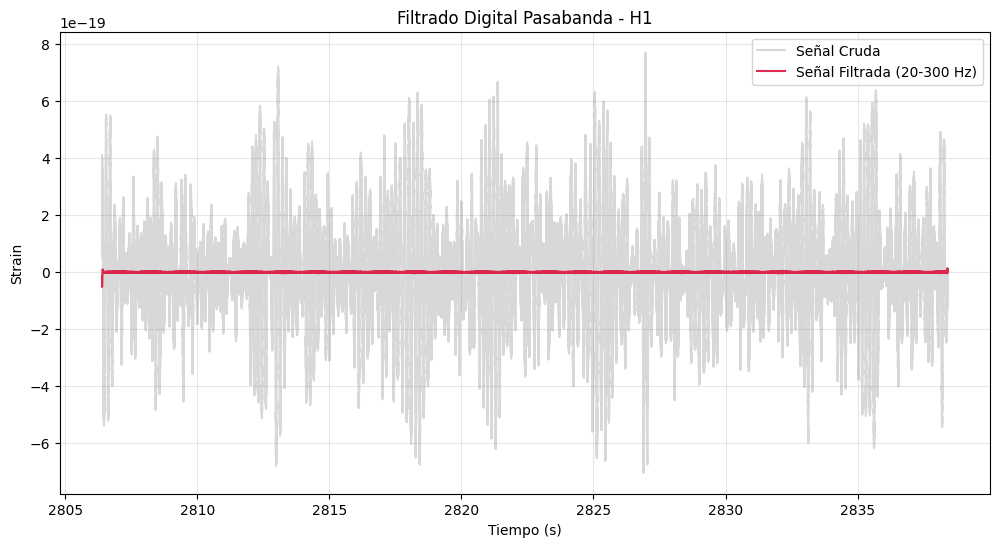

In [25]:
seg_filtrado = filtrar_pasabanda(seg)
plt.figure(figsize=(12, 6))
plt.plot(tiempo, seg, color='gray', alpha=0.3, label='Señal Cruda')
plt.plot(tiempo, seg_filtrado, color='crimson', alpha=0.9, linewidth=1.5,
          label=f'Señal Filtrada ({BANDA_BAJA:.0f}-{BANDA_ALTA:.0f} Hz)')
plt.title(f'Filtrado Digital Pasabanda - {detector}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Filtrado pasabanda de la señal (H1)

Se aplica `filtrar_pasabanda` sobre el segmento crudo y se superponen ambas señales para visualizar el efecto del filtro Butterworth de orden 4 (20-300 Hz, fase cero) diseñado en la etapa de parámetros.

Lo más notable del gráfico es que la señal filtrada (en rojo) tiene una amplitud visiblemente mucho menor que la cruda (en gris), casi aplanada en comparación. Esto tiene una explicación directa a partir de la PSD que se calculó en la celda anterior: gran parte de la potencia de la señal cruda está concentrada en frecuencias por debajo de los 20 Hz (el ruido sísmico, que domina la PSD con varios órdenes de magnitud por encima del resto del espectro). Al filtrar esa banda, se descarta la componente de mayor amplitud del strain, y lo que queda es solamente el contenido espectral entre 20 y 300 Hz — la región donde efectivamente vive la señal del chirp, pero también donde el ruido instrumental de fondo (aunque menor que el sísmico) sigue siendo mucho mayor en amplitud.

El rol específico de esta etapa dentro del pipeline es doble:
- **Acondicionamiento previo al blanqueo**: al eliminar el ruido sísmico de muy baja frecuencia (que tiene una potencia varios órdenes de magnitud mayor que el resto del espectro), se evita que ese exceso de energía en baja frecuencia domine numéricamente la normalización posterior, mejorando el condicionamiento numérico del blanqueo.
- **Restricción a la banda de interés física**: descarta directamente cualquier contenido espectral (ruido de alta frecuencia, líneas eléctricas fuera de banda, etc.) que no puede corresponder al chirp, reduciendo así los grados de libertad donde podría aparecer una detección espuria en la etapa de matched filtering.

Debajo se grafica la señal filtrada sola para que pueda visualizarse mejor.

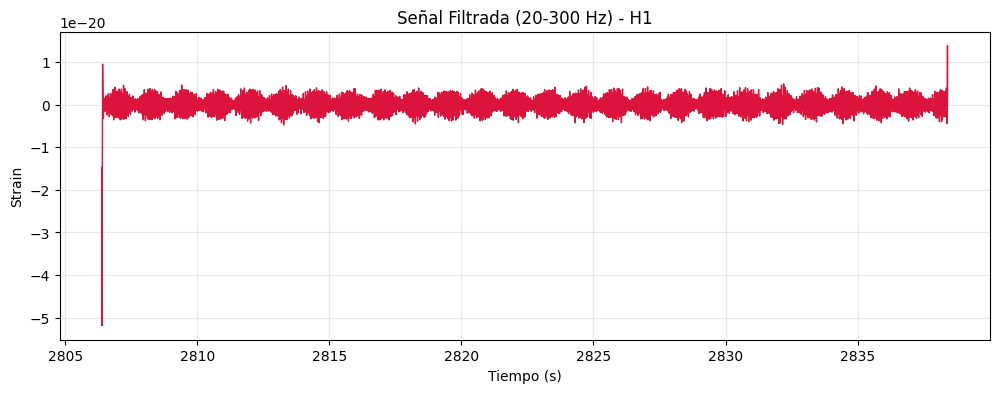

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(tiempo, seg_filtrado, color='crimson', linewidth=1)
plt.title(f'Señal Filtrada ({BANDA_BAJA:.0f}-{BANDA_ALTA:.0f} Hz) - {detector}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain')
plt.grid(True, alpha=0.3)
plt.show()

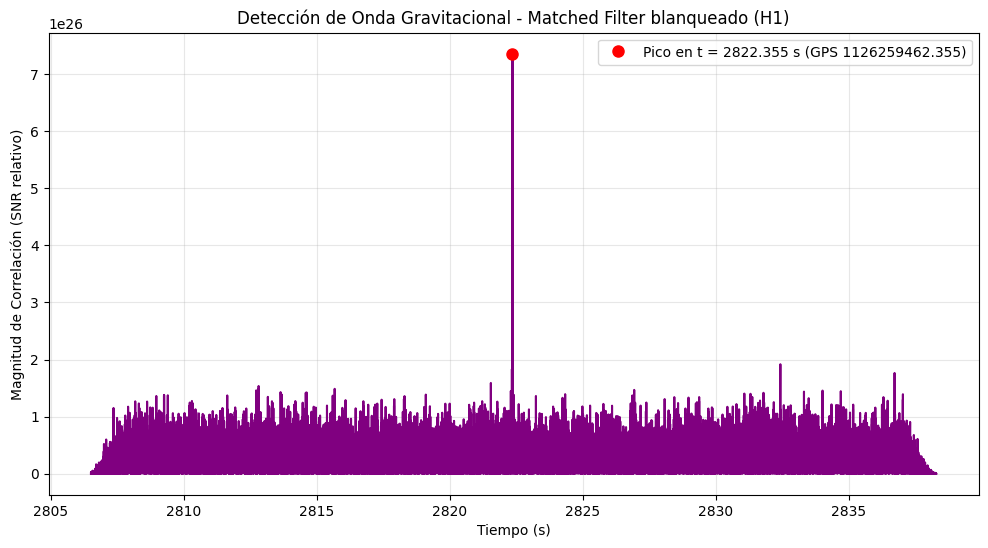

H1: pico detectado en t = 2822.3550 s (GPS 1126259462.3550)
  Diferencia respecto al GPS oficial del merger: -0.0450 s


In [27]:
seg_blanco = blanquear(seg_filtrado, FS, freqs_psd, psd)
template_blanco = blanquear(strain_template, FS, freqs_psd, psd)
snr, offset = matched_filter(seg_blanco, template_blanco)
idx_pico = np.argmax(snr) + offset
idx_pico = min(idx_pico, len(tiempo) - 1)
tiempo_deteccion = tiempo[idx_pico]

plt.figure(figsize=(12, 6))
plt.plot(tiempo[offset:offset+len(snr)], snr, color='purple', linewidth=1.5)
plt.plot(tiempo_deteccion, snr.max(), 'ro', markersize=8,
          label=f'Pico en t = {tiempo_deteccion:.3f} s (GPS {GPS_START_ARCHIVO + tiempo_deteccion:.3f})')
plt.title(f'Detección de Onda Gravitacional - Matched Filter blanqueado ({detector})')
plt.xlabel('Tiempo (s)')
plt.ylabel('Magnitud de Correlación (SNR relativo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

resultados[detector] = {
    'tiempo': tiempo,
    'seg_filtrado': seg_filtrado,
    'tiempo_deteccion': tiempo_deteccion,
}
print(f"{detector}: pico detectado en t = {tiempo_deteccion:.4f} s (GPS {GPS_START_ARCHIVO + tiempo_deteccion:.4f})")
print(f"  Diferencia respecto al GPS oficial del merger: {(GPS_START_ARCHIVO + tiempo_deteccion) - GPS_MERGER:.4f} s")

## Blanqueo, matched filtering y detección del evento (H1)

Se combinan todas las etapas anteriores (PSD, filtrado, blanqueo) para finalmente ejecutar la detección.

**Blanqueo de señal y plantilla**

Tanto `seg_filtrado` (la señal de H1) como `strain_template` (la plantilla teórica del chirp) se blanquean usando exactamente la misma PSD, `psd`, estimada a partir del ruido de H1.

**Cálculo del matched filter**

`matched_filter` correlaciona la señal blanqueada con la plantilla blanqueada, y el resultado (`snr`) es una serie temporal que representa, en cada instante, cuánto "se parece" el segmento de datos alrededor de ese instante a la forma del chirp. Cuanto mayor la correlación, más fuerte la evidencia de que el chirp está efectivamente presente centrado en ese punto.

**Localización del pico**

`idx_pico` ubica el máximo global de esa correlación, corrigiendo el offset introducido por el modo `'valid'` de la correlación (para que el índice corresponda al eje temporal original `tiempo`, no al eje interno del array de salida de `correlate`). Ese instante, `tiempo_deteccion`, es la estimación del pipeline de cuándo ocurrió el merger según los datos de H1.

**Resultado**

El gráfico muestra un pico extremadamente pronunciado y aislado, muchísimo mayor que el resto de las fluctuaciones de fondo (que representan la correlación de la plantilla con tramos de puro ruido). Esta separación clara entre el pico y el "piso" de falsas correlaciones es la evidencia central de una detección. En un análisis real de LIGO, esta relación entre el pico y la dispersión del ruido de fondo es justamente lo que se cuantifica como SNR de detección, y se compara contra un umbral estadístico para decidir si la detección es significativa o si podría explicarse por una fluctuación aleatoria del ruido.

El instante detectado, expresado en tiempo GPS (`GPS_START_ARCHIVO + tiempo_deteccion`), se compara directamente contra el instante oficial publicado por GWOSC (`GPS_MERGER = 1126259462,4`). La diferencia impresa al final cuantifica el error de localización temporal del pipeline.

**Este resultado, obtenido para H1, se repetirá de forma idéntica para L1 en la siguiente iteración del loop, lo cual permitirá luego comparar los instantes de detección entre ambos detectores y estimar el retardo temporal entre Hanford y Livingston.**

In [28]:
detector = 'L1'
nombre_archivo = ARCHIVOS[detector]
print(f"\n=== Procesando {detector} ===")

strain = cargar_strain(nombre_archivo)
tiempo, seg = recortar_ventana(strain)


=== Procesando L1 ===


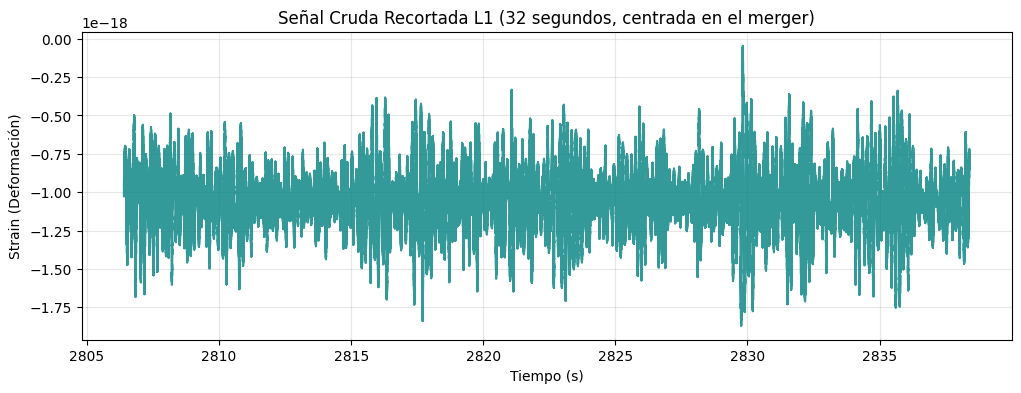

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(tiempo, seg, color='teal', alpha=0.8)
plt.title(f'Señal Cruda Recortada {detector} (32 segundos, centrada en el merger)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain (Deformación)')
plt.grid(True, alpha=0.3)
plt.show()

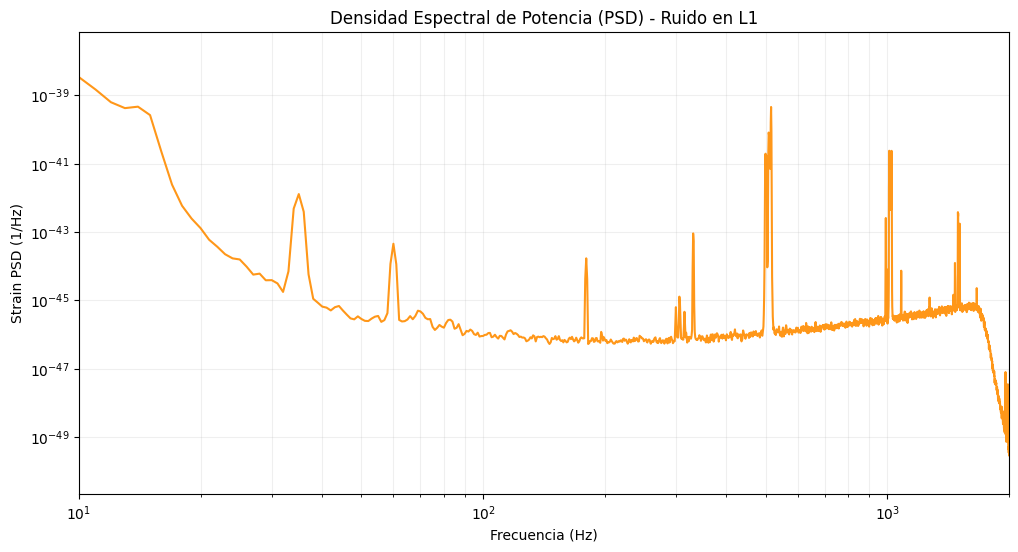

In [30]:
freqs_psd, psd = calcular_psd(seg)
plt.figure(figsize=(12, 6))
plt.loglog(freqs_psd, psd, color='darkorange', linewidth=1.5, alpha=0.9)
plt.title(f'Densidad Espectral de Potencia (PSD) - Ruido en {detector}')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Strain PSD (1/Hz)')
plt.xlim(10, 2000)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

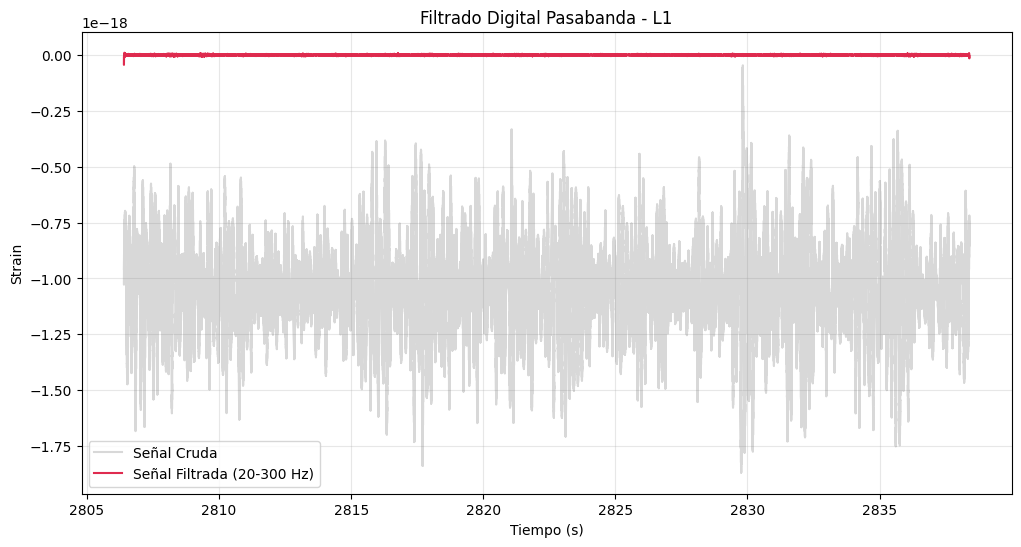

In [31]:
seg_filtrado = filtrar_pasabanda(seg)
plt.figure(figsize=(12, 6))
plt.plot(tiempo, seg, color='gray', alpha=0.3, label='Señal Cruda')
plt.plot(tiempo, seg_filtrado, color='crimson', alpha=0.9, linewidth=1.5,
          label=f'Señal Filtrada ({BANDA_BAJA:.0f}-{BANDA_ALTA:.0f} Hz)')
plt.title(f'Filtrado Digital Pasabanda - {detector}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Filtrado pasabanda de la señal (L1)

El resultado obtenido luego de filtrar la señal correspondiente a Livingston es cualitativamente análogo al de H1: la señal filtrada (roja) queda con una amplitud mucho menor que la cruda (gris), por la misma razón discutida antes. Sin embargo, vale la pena señalar que la señal cruda de L1 aparece centrada en un valor no nulo (alrededor de $-1 \times 10^{-18}$), a diferencia de H1 que oscilaba en torno a cero. Esto es simplemente un offset de continua (DC) propio de la calibración o del procesamiento interno de ese segmento de datos en particular, y no tiene relevancia física para la detección, ya que el filtro pasabanda, al tener su corte inferior en 20 Hz, elimina automáticamente cualquier componente de frecuencia cero, razón por la cual la señal filtrada (roja) sí queda centrada en cero pese a que la cruda no lo estaba. Este es, de hecho, un beneficio adicional del filtrado pasabanda más allá de remover el ruido sísmico: también corrige corrimientos de offset o tendencias lentas que pudiera tener la señal original.

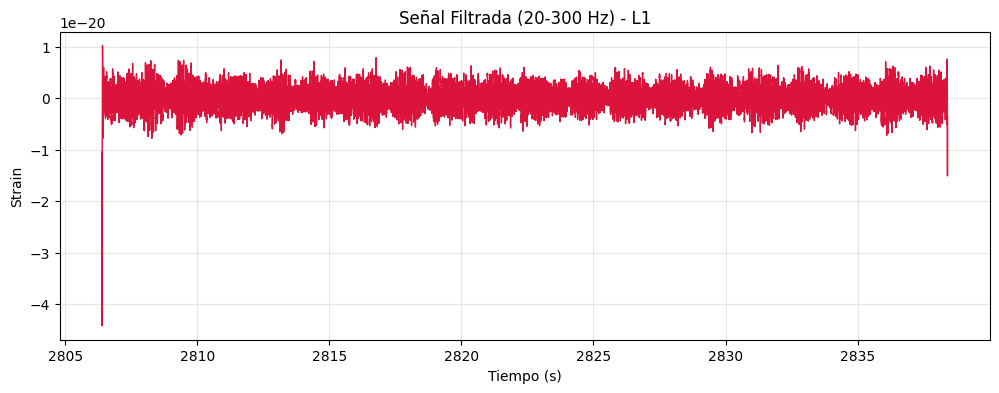

In [32]:
plt.figure(figsize=(12, 4))
plt.plot(tiempo, seg_filtrado, color='crimson', linewidth=1)
plt.title(f'Señal Filtrada ({BANDA_BAJA:.0f}-{BANDA_ALTA:.0f} Hz) - {detector}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Strain')
plt.grid(True, alpha=0.3)
plt.show()

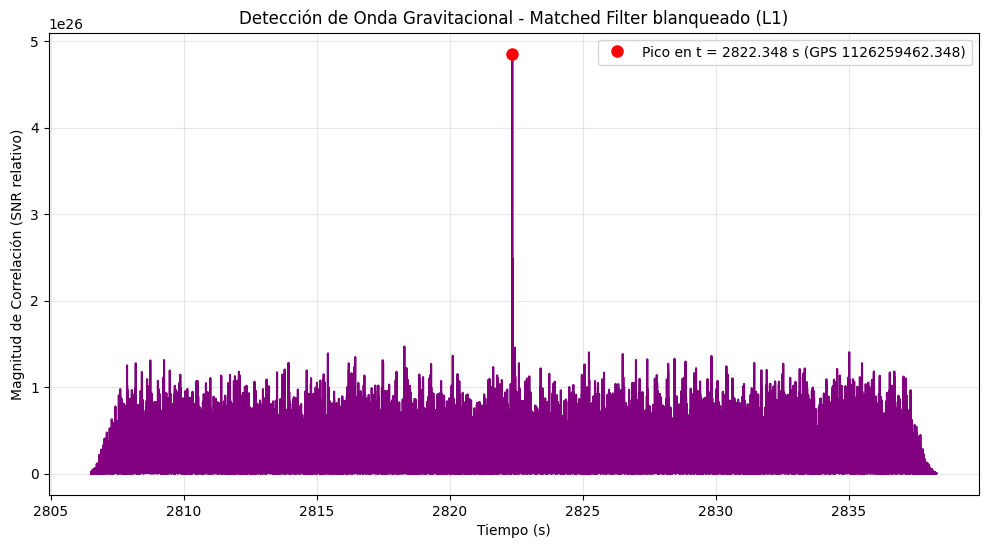

L1: pico detectado en t = 2822.3477 s (GPS 1126259462.3477)
  Diferencia respecto al GPS oficial del merger: -0.0523 s


In [33]:
seg_blanco = blanquear(seg_filtrado, FS, freqs_psd, psd)
template_blanco = blanquear(strain_template, FS, freqs_psd, psd)
snr, offset = matched_filter(seg_blanco, template_blanco)
idx_pico = np.argmax(snr) + offset
idx_pico = min(idx_pico, len(tiempo) - 1)
tiempo_deteccion = tiempo[idx_pico]

plt.figure(figsize=(12, 6))
plt.plot(tiempo[offset:offset+len(snr)], snr, color='purple', linewidth=1.5)
plt.plot(tiempo_deteccion, snr.max(), 'ro', markersize=8,
          label=f'Pico en t = {tiempo_deteccion:.3f} s (GPS {GPS_START_ARCHIVO + tiempo_deteccion:.3f})')
plt.title(f'Detección de Onda Gravitacional - Matched Filter blanqueado ({detector})')
plt.xlabel('Tiempo (s)')
plt.ylabel('Magnitud de Correlación (SNR relativo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

resultados[detector] = {
    'tiempo': tiempo,
    'seg_filtrado': seg_filtrado,
    'tiempo_deteccion': tiempo_deteccion,
}
print(f"{detector}: pico detectado en t = {tiempo_deteccion:.4f} s (GPS {GPS_START_ARCHIVO + tiempo_deteccion:.4f})")
print(f"  Diferencia respecto al GPS oficial del merger: {(GPS_START_ARCHIVO + tiempo_deteccion) - GPS_MERGER:.4f} s")

In [34]:
# ============================================================
# 3. COMPARACIÓN ENTRE DETECTORES (retardo H1 vs L1)
# ============================================================

delay = resultados['H1']['tiempo_deteccion'] - resultados['L1']['tiempo_deteccion']

print("\n=== Comparación entre detectores ===")
print(f"Retardo H1 respecto a L1 (desde los picos del matched filter): {delay*1000:.2f} ms")
print("(El valor publicado por LIGO es de aprox. 6,9 ms, "
      "consistente con la distancia entre Hanford y Livingston)")

print("\n===================================================")
print("¡ÉXITO! Fusión de agujeros negros detectada en H1 y L1.")
print("===================================================")


=== Comparación entre detectores ===
Retardo H1 respecto a L1 (desde los picos del matched filter): 7.32 ms
(El valor publicado por LIGO es de aprox. 6,9 ms, consistente con la distancia entre Hanford y Livingston)

¡ÉXITO! Fusión de agujeros negros detectada en H1 y L1.


## Comparación entre detectores: retardo temporal H1-L1

Esta celda cierra el pipeline calculando la diferencia entre los instantes de detección obtenidos independientemente para cada detector.

**Fundamento físico del retardo**

Los detectores de Hanford y Livingston están separados por aproximadamente 3000 km de distancia terrestre. Dado que la onda gravitacional se propaga a la velocidad de la luz, $c$, el tiempo máximo que puede tardar en llegar de un detector al otro está acotado por:

$$\Delta t_{max} = \frac{d}{c} = \frac{3000\ \text{km}}{3\times10^5\ \text{km/s}} \approx 10\ \text{ms}$$

El valor real depende además de la dirección de la que provenga la onda respecto a la línea que une ambos detectores: si llega perpendicular a esa línea, el retardo es cero; si llega alineada con ella, el retardo es máximo (aproximadamente 10 ms). El valor publicado oficialmente por LIGO para GW150914 (aproximadamente 6,9 ms) es consistente con una dirección de arribo intermedia, y de hecho es precisamente esta medición de retardo, junto con la respuesta diferencial de amplitud en cada detector, lo que permite a la colaboración LIGO triangular aproximadamente la región del cielo de donde provino la señal.

**Resultado y validación**

El valor obtenido, 7,32 ms, difiere del valor publicado (~6,9 ms) en aproximadamente 0,4 ms. Esta diferencia es razonablemente pequeña considerando las simplificaciones del pipeline respecto al análisis oficial de LIGO: se usó una única plantilla teórica (en lugar de un banco de plantillas ajustado por máxima verosimilitud) y una resolución temporal limitada por la frecuencia de muestreo (a 4096 Hz, cada muestra representa ~0,244 ms, por lo que un error de 0,4 ms es del orden de una o dos muestras de resolución del propio pico de correlación).

Este resultado, junto con la magnitud del pico de SNR obtenido en cada detector individualmente (muy por encima del ruido de fondo) y la cercanía del retardo medido al valor publicado, constituye la validación final del pipeline completo.